In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/ybifoundation/Dataset/main/Salary%20Data.csv"

df = pd.read_csv(url)

print(df.head())

   Experience Years  Salary
0               1.1   39343
1               1.2   42774
2               1.3   46205
3               1.5   37731
4               2.0   43525


In [2]:
print(df.shape)

print(df.info())

print(df.describe())

(40, 2)
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes
None
       Experience Years         Salary
count         40.000000      40.000000
mean           5.152500   74743.625000
std            2.663715   25947.122885
min            1.100000   37731.000000
25%            3.200000   56878.250000
50%            4.600000   64472.500000
75%            6.875000   95023.250000
max           10.500000  122391.000000


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

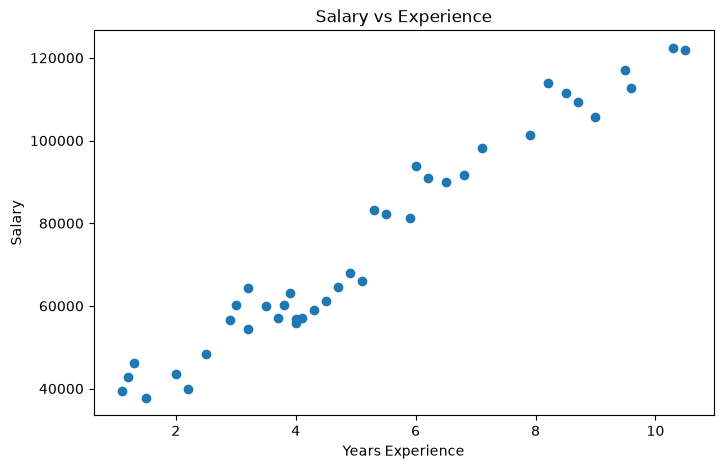

In [5]:
plt.figure(figsize=(8,5))

plt.scatter(df['Experience Years'], df['Salary'])

plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')

plt.show()

In [7]:
X = df[['Experience Years']]
y = df['Salary']

In [8]:
print(X.shape)
print(y.shape)

(40, 1)
(40,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(32, 1)
(8, 1)


In [11]:
lr = LinearRegression()

In [12]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9408.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Experience Years']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.672e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [13]:
print("Slope =", lr.coef_[0])
print("Intercept =", lr.intercept_)

Slope = 9408.03127250658
Intercept = 26716.250176145535


In [14]:
y_pred = lr.predict(X_test)

In [15]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result

,Actual,Predicted
19,61111,69052.390902
16,56957,64348.375266
15,55794,64348.375266
26,93940,83164.437811
4,43525,45532.312721
12,57189,61525.965884
37,112635,117033.350392
27,91000,85046.044066


In [16]:
mean_absolute_error(y_test, y_pred)

6419.911069460598

In [17]:
mean_squared_error(y_test, y_pred)

48077731.16919359

In [18]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(6933.810724932834)

In [19]:
r2_score(y_test, y_pred)

0.9068577573647874

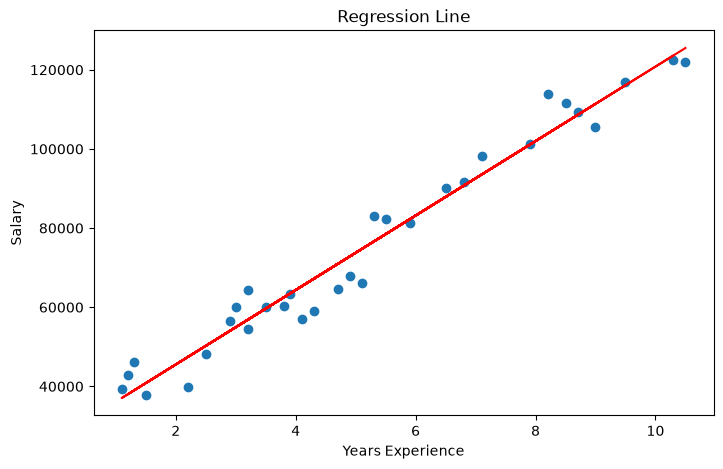

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train)

plt.plot(
    X_train,
    lr.predict(X_train),
    color='red'
)

plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.title('Regression Line')

plt.show()

In [21]:
lr.predict([[7]])

C:\Users\mohdr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92572.46908369])